## Berechnung TP4

### $\underline{H}_{TP2}(s)=\frac{1}{1+(R_1+R_2)\ C_2\ s\ +\ C_1\ C_2\ R_1\ R_2\ s²}$

### $R_1 = \frac{\sqrt{\frac{-4 \ C_2\ Q^2\ +\ C_1}{C_1}}+1}{2\ C_2\ Q\ \omega_r};\quad R_2 = \frac{1}{\omega_r^2\ C_1\ C_2\ R_1};\quad R=R_1=R_2=\frac{1}{2\ C_2\ Q\ \omega_r}$

In [1]:
#Festlegung der bibliotheken und Parameter
import numpy as np
import matplotlib.pyplot as plt

pi      = np.pi
omega   = np.logspace(1, 6, 2000)
f       = omega / (2 * pi)

In [2]:
# Filter Charakteristik TP4
def H_TP4(Q_1, Q_2, f_r, C_2, C_4):
    
    omega_r = 2 * pi * f_r
    C_1     = 4 * Q_1**2 * C_2
    R_1     = (np.sqrt((-4 * C_2 * Q_1**2 + C_1) / (C_1)) + 1) / (2 * C_2 * Q_1 * omega_r)
    R_2     = 1 / (omega_r**2 * C_1 * C_2 * R_1)
    R_12       = 1 / (2 * C_2 * Q_1 * omega_r)
    H1_TP2  = 1 / (1 + (R_1 + R_2) * C_2 * 1j * omega + C_1 * C_2 * R_1 * R_2 * (1j * omega)**2)

    C_3     = 4 * Q_2**2 * C_4
    R_3     = (np.sqrt((-4 * C_4 * Q_2**2 + C_3) / (C_3)) + 1) / (2 * C_4 * Q_2 * omega_r)
    R_4     = 1 / (omega_r**2 * C_3 * C_4 * R_3)
    R_34       = 1 / (2 * C_4 * Q_2 * omega_r)
    H2_TP2  = 1 / (1 + (R_3 + R_4) * C_4 * 1j * omega + C_3 * C_4 * R_3 * R_4 * (1j * omega)**2)
    
    #Linkwitz Riley TP4
    H1_TP4 = H1_TP2 * H2_TP2
    H1_TP4_abs   = np.abs(H1_TP4)
    H1_TP4_phase = np.unwrap(np.angle(H1_TP4)) * (180 / np.pi)
    
    print(f"C_1 = {C_1/1e-9:.3f} nF")
    print(f"C_2 = {C_2/1e-9:.3f} nF")
    print(f"R_1 = {R_1/1e3:.3f} kΩ")
    print(f"R_2 = {R_2/1e3:.3f} kΩ")
    #print(f"R   = {R_12  /1e3:.3f} kΩ")
    print(f"C_3 = {C_3/1e-9:.3f} nF")
    print(f"C_4 = {C_4/1e-9:.3f} nF")
    print(f"R_3 = {R_3/1e3:.3f} kΩ")
    print(f"R_4 = {R_4/1e3:.3f} kΩ")
    #print(f"R   = {R_34  /1e3:.3f} kΩ")
    
    plt.subplot(2,1,1)
    plt.semilogx(f, 20 * np.log10(H1_TP4_abs), label="Amplitudengang")
    plt.ylabel("Amplitude (dB)")
    plt.grid(True, which="both")
    plt.ylim(-60,20)
    plt.xlim(1e1,1e5)
    
    plt.subplot(2,1,2)
    plt.semilogx(f, H1_TP4_phase, label="Phasengang")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Phase (Grad)")
    plt.grid(True, which="both")
    plt.ylim(-400,40)
    plt.yticks([-360,-270,-180,-90,0])
    plt.xlim(1e1,1e5)
    plt.show()
    return H1_TP4

## Plot TP4_1

C_1 = 2.566 nF
C_2 = 2.200 nF
R_1 = 3.940 kΩ
R_2 = 3.940 kΩ
C_3 = 6.864 nF
C_4 = 1.000 nF
R_3 = 3.573 kΩ
R_4 = 3.573 kΩ


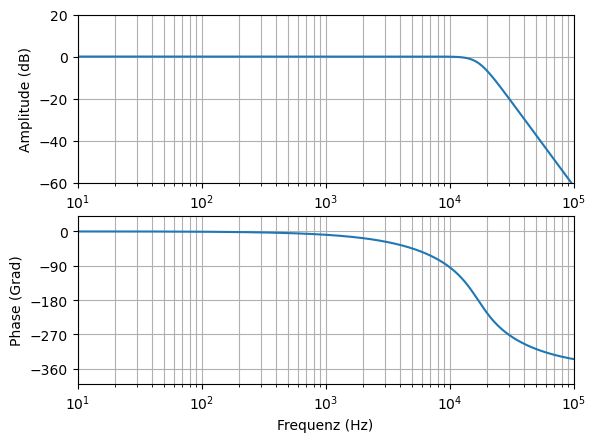

In [19]:
H1_LR_TP4 = H_TP4(Q_1=0.54, Q_2=1.31, f_r=17e3, C_2=2.2e-9, C_4=1e-9)

## Berechnung HP4

### $\underline{H}_{HP2}(s)=\frac{C_1\ C_2\ R_1\ R_2\ s^2}{1+(C_1+C_2)\ R_1\ s\ +\ C_1\ C_2\ R_1\ R_2\ s²}$

### $R_1 = \frac{1}{(C_1 + C_2)\ Q\ \omega_r};\quad R_2 = \frac{1}{\omega_r^2\ C_1\ C_2\ R_1}$

In [4]:
#Festlegung der bibliotheken und Parameter
import numpy as np
import matplotlib.pyplot as plt

pi      = np.pi
omega   = np.logspace(1, 6, 2000)
f       = omega / (2 * pi)

In [5]:
# Filter Charakteristik erste Stufe Buterworth HP4

def H_HP4(Q_1, Q_2, f_r, C_2, C_4):

    omega_r = 2 * pi * f_r
    C_1     = C_2
    R_1     = 1 / ((C_1 + C_2) * Q_1 * omega_r)
    R_2     = 1 / (omega_r**2 * C_1 * C_2 * R_1)
    R_12    = 1 / (2 * C_2 * Q_1 * omega_r)
    H1_HP2  = (C_1 * C_2 * R_1 * R_2 * (1j * omega)**2) / (1 + (C_1 + C_2) * R_1 * 1j * omega + C_1 * C_2 * R_1 * R_2 * (1j * omega)**2)
    
    # Filter Charakteristik zweite Stufe Buterworth HP2
    C_3     = C_4
    R_3     = 1 / ((C_3 + C_4) * Q_2 * omega_r)
    R_4     = 1 / (omega_r**2 * C_3 * C_4 * R_3)
    R_34       = 1 / (2 * C_4 * Q_2 * omega_r)
    H2_HP2  = (C_3 * C_4 * R_3 * R_4 * (1j * omega)**2) / (1 + (C_3 + C_4) * R_3 * 1j * omega + C_3 * C_4 * R_3 * R_4 * (1j * omega)**2)
    
    #Buterworth HP4
    H1_HP4 = H1_HP2*H2_HP2
    H1_HP4_abs   = np.abs(H1_HP4)
    H1_HP4_phase = np.unwrap(np.angle(H1_HP4)) * (180 / np.pi)
    
    print(f"C_1 = {C_1/1e-9:.3f} nF")
    print(f"C_2 = {C_2/1e-9:.3f} nF")
    print(f"R_1 = {R_1/1e3:.3f} kΩ")
    print(f"R_2 = {R_2/1e3:.3f} kΩ")

    print(f"C_3 = {C_3/1e-9:.3f} nF")
    print(f"C_4 = {C_4/1e-9:.3f} nF")
    print(f"R_3 = {R_3/1e3:.3f} kΩ")
    print(f"R_4 = {R_4/1e3:.3f} kΩ")
    
    plt.subplot(2,1,1)
    plt.semilogx(f, 20 * np.log10(H1_HP4_abs), label="Amplitudengang")
    plt.ylabel("Amplitude (dB)")
    plt.grid(True, which="both")
    plt.ylim(-60,20)
    plt.xlim(1e1,1e5)
    
    plt.subplot(2,1,2)
    plt.semilogx(f, H1_HP4_phase, label="Phasengang")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Phase (Grad)")
    plt.grid(True, which="both")
    plt.ylim(-400,40)
    plt.yticks([-360,-270,-180,-90,0])
    plt.xlim(1e1,1e5)
    plt.show()
    return H1_HP4

## Plot HP4_1

C_1 = 1.500 nF
C_2 = 1.500 nF
R_1 = 15.249 kΩ
R_2 = 30.748 kΩ
C_3 = 1.500 nF
C_4 = 1.500 nF
R_3 = 15.249 kΩ
R_4 = 30.748 kΩ


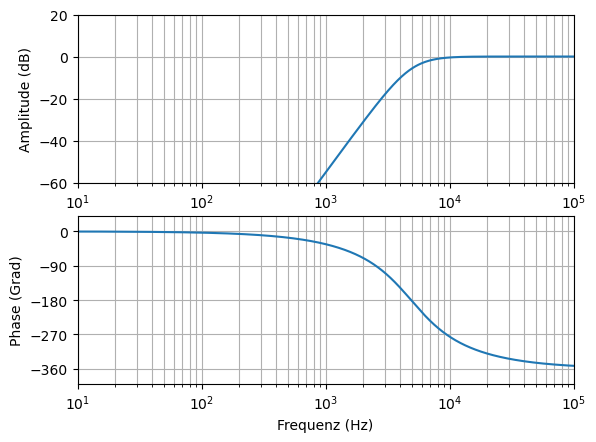

In [11]:
H1_BW_HP4 = H_HP4(Q_1=0.71,Q_2=0.71,f_r=4.9e3,C_2=1.5e-9,C_4=1.5e-9)

## Bandpass Zusammengestezt aus HP4_1 und TP4_1

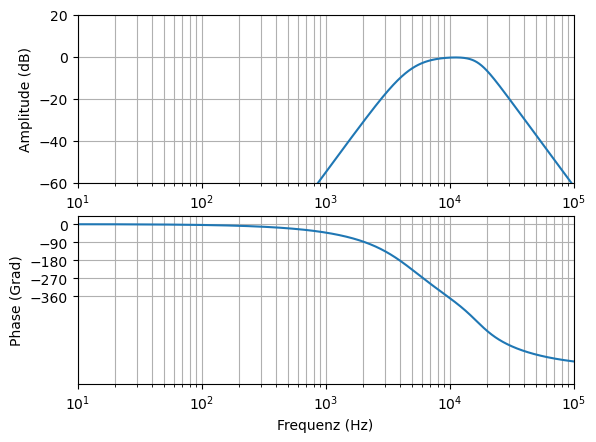

In [20]:
H1_BP8_abs   = np.abs(H1_LR_TP4*H1_BW_HP4)
H1_BP8_phase = np.unwrap(np.angle(H1_LR_TP4*H1_BW_HP4)) * (180 / np.pi)

plt.subplot(2,1,1)
plt.semilogx(f, 20 * np.log10(H1_BP8_abs), label="Amplitudengang")
plt.ylabel("Amplitude (dB)")
plt.grid(True, which="both")
plt.ylim(-60,20)
plt.xlim(1e1,1e5)

plt.subplot(2,1,2)
plt.semilogx(f, H1_BP8_phase, label="Phasengang")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Phase (Grad)")
plt.grid(True, which="both")
plt.ylim(-800,40)
plt.yticks([-360,-270,-180,-90,0])
plt.xlim(1e1,1e5)
plt.show()